In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Unemployment_Rate_upto_11_2020.csv to Unemployment_Rate_upto_11_2020 (1).csv
Saving Unemployment in India.csv to Unemployment in India (1).csv


Files in /content/: ['.config', 'Unemployment in India.csv', 'sample_data']
First look at the data:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                 

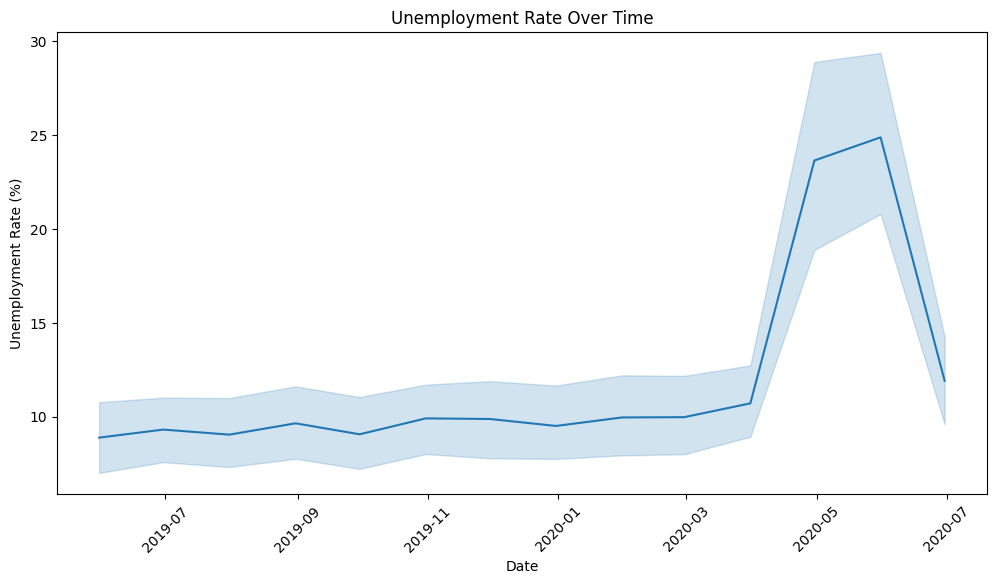

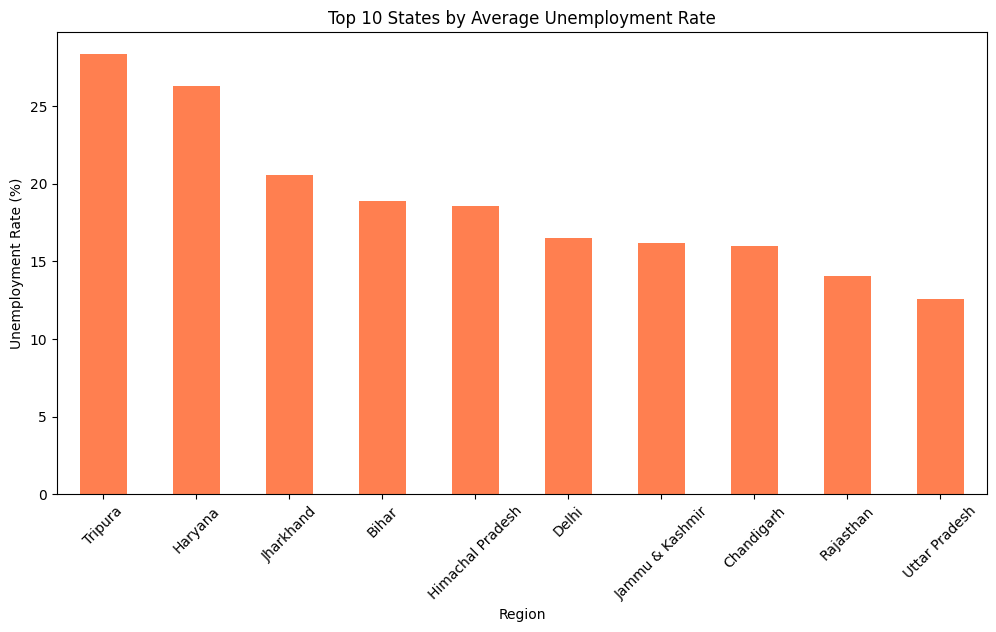

Average unemployment rate by year:
 Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64


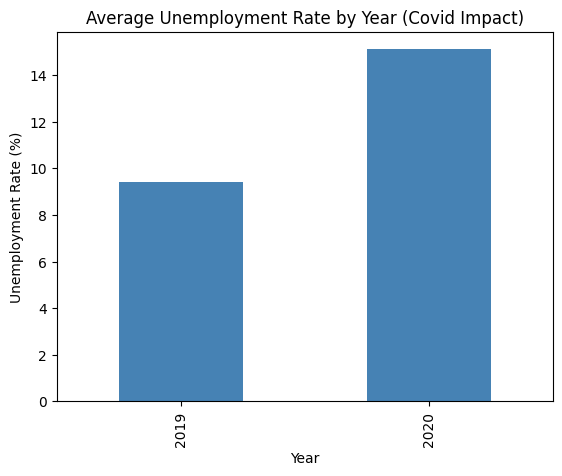

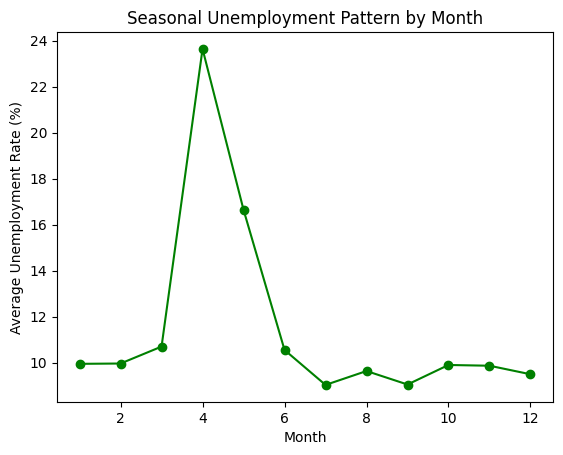

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Files in /content/:", os.listdir('/content/'))

df = pd.read_csv('/content/Unemployment in India.csv')
print ("First look at the data:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
df.columns = df.columns.str.strip()
print("Missing values:\n", df.isnull().sum())
df= df.dropna()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
print(df.describe())
print(df['Region'].unique())

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)')
plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,6))
top_states = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)
top_states.plot(kind='bar', color='coral')
plt.title('Top 10 States by Average Unemployment Rate')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

df['Year'] = df['Date'].dt.year
yearly_avg = df.groupby('Year')['Estimated Unemployment Rate (%)'].mean()
print("Average unemployment rate by year:\n", yearly_avg)

yearly_avg.plot(kind='bar', color='steelblue')
plt.title('Average Unemployment Rate by Year (Covid Impact)')
plt.ylabel('Unemployment Rate (%)')
plt.show()

df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly_avg.plot(kind='line', marker='o', color='green')
plt.title('Seasonal Unemployment Pattern by Month')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.show()